# LLM Executor H/k Example Analysis

This notebook is the execution and analysis surface for the current Planner / LLM Executor / Evaluator / Controller prototype.

It focuses on the hardcoded example tasks plus the longer GitLab Task 105:

- GitLab Task `44`
- Shopping Admin Task `157`
- Reddit Task `27`
- Shopping Task `118`
- GitLab long Task `105`

The runs intentionally use `--target-hint-mode none`, so the agent does not receive evaluator-derived target URLs. The official WebArena-Verified evaluator is still used after execution when available.


In [2]:
from pathlib import Path
import json
import os
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

RUN_ROOT = ROOT / 'runs' / 'hk-test'

pd.set_option('display.max_colwidth', 180)
pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-whitegrid')

EXAMPLE_TASKS = [44, 157, 27, 118, 105]
TASK_LABELS = {
    44: 'gitlab-44',
    157: 'shopping_admin-157',
    27: 'reddit-27',
    118: 'shopping-118',
    105: 'gitlab-105-long',
}


def read_json(path: Path):
    return json.loads(path.read_text())


def read_jsonl(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    return pd.DataFrame([json.loads(line) for line in path.read_text().splitlines() if line.strip()])


def run_command(command, env=None):
    merged_env = os.environ.copy()
    merged_env['PYTHONUNBUFFERED'] = '1'
    if env:
        merged_env.update(env)
    print('$ ' + ' '.join(command), flush=True)
    proc = subprocess.Popen(
        command,
        cwd=ROOT,
        env=merged_env,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        bufsize=1,
    )
    output_lines = []
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end='', flush=True)
        output_lines.append(line)
    returncode = proc.wait()
    completed = subprocess.CompletedProcess(command, returncode, stdout=''.join(output_lines), stderr='')
    if returncode != 0:
        raise RuntimeError(f'Command failed with return code {returncode}')
    return completed


def load_summary(experiment_name: str) -> pd.DataFrame:
    path = RUN_ROOT / experiment_name / 'summary.json'
    if not path.exists():
        print('Missing summary:', path)
        return pd.DataFrame()
    data = read_json(path)
    rows = data.get('rows', [])
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df['experiment'] = experiment_name
    df['task_label'] = df['task_id'].map(TASK_LABELS).fillna(df['task_id'].astype(str))
    df['hk'] = 'H=' + df['h'].astype(str) + ', k=' + df['k'].astype(str)
    return df


def show_bar(ax, values, title, ylabel=None, ylim=None, color='#4c78a8'):
    values.plot(kind='bar', ax=ax, color=color, rot=35)
    ax.set_title(title)
    ax.set_ylabel(ylabel or '')
    if ylim:
        ax.set_ylim(*ylim)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3g', padding=3)

ROOT


PosixPath('/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code')

## Run Configuration

Set `RUN_LLM_EXECUTOR_EXAMPLES = True` to execute the full example sweep. This runs 5 tasks with 3 H-values and 2 k-values, so 30 task runs. Keep it `False` when you only want to inspect existing artifacts.


In [4]:
RUN_LLM_EXECUTOR_EXAMPLES = True

PLANNER_MODEL = 'gemma4:26b'
EXECUTOR_MODEL = 'gemma3:12b'
EXPERIMENT_NAME = 'llm-executor-hk-examples-gemma4-planner-gemma3-executor'

GITLAB_VERIFIED_ENV = {
    'WA_GITLAB': 'http://localhost:8023',
    'WA_GITLAB_USERNAME': 'byteblaze',
    'WA_GITLAB_PASSWORD': 'hello1234',
}

LLM_EXECUTOR_EXAMPLE_COMMAND = [
    'uv', 'run', 'python', 'scripts/main_execution.py',
    '--task-ids', '44', '157', '27', '118', '105',
    '--experiment-name', EXPERIMENT_NAME,
    '--hs', '0', '1', '2',
    '--ks', '1', '2',
    '--planner-mode', 'ollama',
    '--executor-mode', 'llm',
    '--model', PLANNER_MODEL,
    '--executor-model', EXECUTOR_MODEL,
    '--target-hint-mode', 'none',
    '--max-planner-calls', '3',
    '--max-steps', '8',
]

if RUN_LLM_EXECUTOR_EXAMPLES:
    run_command(LLM_EXECUTOR_EXAMPLE_COMMAND, env=GITLAB_VERIFIED_ENV)
else:
    print('Run disabled. To execute, set RUN_LLM_EXECUTOR_EXAMPLES = True and rerun this cell.')
    print('$ ' + ' '.join(LLM_EXECUTOR_EXAMPLE_COMMAND))


$ uv run python scripts/main_execution.py --task-ids 44 157 27 118 105 --experiment-name llm-executor-hk-examples-gemma4-planner-gemma3-executor --hs 0 1 2 --ks 1 2 --planner-mode ollama --executor-mode llm --model gemma4:26b --executor-model gemma3:12b --target-hint-mode none --max-planner-calls 3 --max-steps 8

main execution:   0%|          | 0/30 [00:00<?, ?run/s]
                                                       
$ /Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/.venv/bin/python3 scripts/run_hk_task.py --repo-root /Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/external/webarena-verified --site gitlab --task-id 44 --output-root /Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/gitlab/44/h0_k1 --h 0 --k 1 --planner-mode ollama --executor-mode llm --model gemma4:26b --target-hint-mode none --max-steps 8 --max-planner-calls 3 --executor-model gemma3:12b

ma

RuntimeError: Command failed with return code 1

## Load Results

This loads the configured experiment. If it has not been executed yet, the following cells show a missing summary message instead of failing hard.


In [5]:
df = load_summary(EXPERIMENT_NAME)

if df.empty:
    print('No rows loaded yet.')
else:
    metric_cols = [
        'task_id', 'task_label', 'site', 'h', 'k', 'status', 'score', 'success',
        'total_steps', 'total_runtime_ms', 'total_tokens', 'executor_tokens',
        'num_planner_calls', 'num_executor_calls', 'num_replans', 'final_url', 'output_dir',
    ]
    display(df[[col for col in metric_cols if col in df.columns]].sort_values(['task_id', 'h', 'k']))


,task_id,task_label,site,h,k,status,score,success,total_steps,total_runtime_ms,total_tokens,executor_tokens,num_planner_calls,num_executor_calls,num_replans,final_url,output_dir
12,27,reddit-27,reddit,0,1,completed,1.0,True,1.0,37019.0,3555.0,1147.0,1.0,1.0,0.0,http://localhost:9999/forums,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/reddit/27/h0_k1/27
13,27,reddit-27,reddit,0,2,completed,1.0,True,1.0,66984.0,5156.0,1159.0,1.0,1.0,0.0,http://localhost:9999/forums,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/reddit/27/h0_k2/27
14,27,reddit-27,reddit,1,1,completed,1.0,True,1.0,60848.0,4739.0,1223.0,1.0,1.0,0.0,http://localhost:9999/forums,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/reddit/27/h1_k1/27
15,27,reddit-27,reddit,1,2,completed,1.0,True,1.0,108971.0,7075.0,1214.0,1.0,1.0,0.0,http://localhost:9999/forums,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/reddit/27/h1_k2/27
16,27,reddit-27,reddit,2,1,completed,1.0,True,1.0,52379.0,4354.0,1172.0,1.0,1.0,0.0,http://localhost:9999/forums,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/reddit/27/h2_k1/27
17,27,reddit-27,reddit,2,2,completed,1.0,True,1.0,59332.0,4796.0,1155.0,1.0,1.0,0.0,http://localhost:9999/forums,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/reddit/27/h2_k2/27
0,44,gitlab-44,gitlab,0,1,completed,1.0,True,2.0,73660.0,4462.0,2000.0,1.0,1.0,0.0,http://localhost:8023/dashboard/todos,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/gitlab/44/h0_k1/44
1,44,gitlab-44,gitlab,0,2,completed,1.0,True,2.0,47961.0,4392.0,2000.0,1.0,1.0,0.0,http://localhost:8023/dashboard/todos,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/gitlab/44/h0_k2/44
2,44,gitlab-44,gitlab,1,1,completed,1.0,True,2.0,87456.0,8142.0,1996.0,2.0,1.0,0.0,http://localhost:8023/dashboard/todos,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/gitlab/44/h1_k1/44
3,44,gitlab-44,gitlab,1,2,completed,1.0,True,2.0,121786.0,9146.0,1990.0,2.0,1.0,0.0,http://localhost:8023/dashboard/todos,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/gitlab/44/h1_k2/44


## Overall Metrics

These plots show aggregate behavior across the example tasks. `score` is the official WebArena-Verified score when evaluation is available.


,mean_score,success_rate,mean_runtime_ms,mean_tokens,mean_replans
hk,,,,,
"H=0, k=1",1.0,1.0,58556.25,4902.50,0.0
"H=0, k=2",1.0,1.0,56989.75,5224.25,0.0
"H=1, k=1",0.8,0.8,104453.20,9471.20,0.4
"H=1, k=2",1.0,1.0,98735.00,8981.20,0.2
"H=2, k=1",1.0,1.0,110241.60,9806.00,0.6
"H=2, k=2",1.0,1.0,98334.40,8935.00,0.2


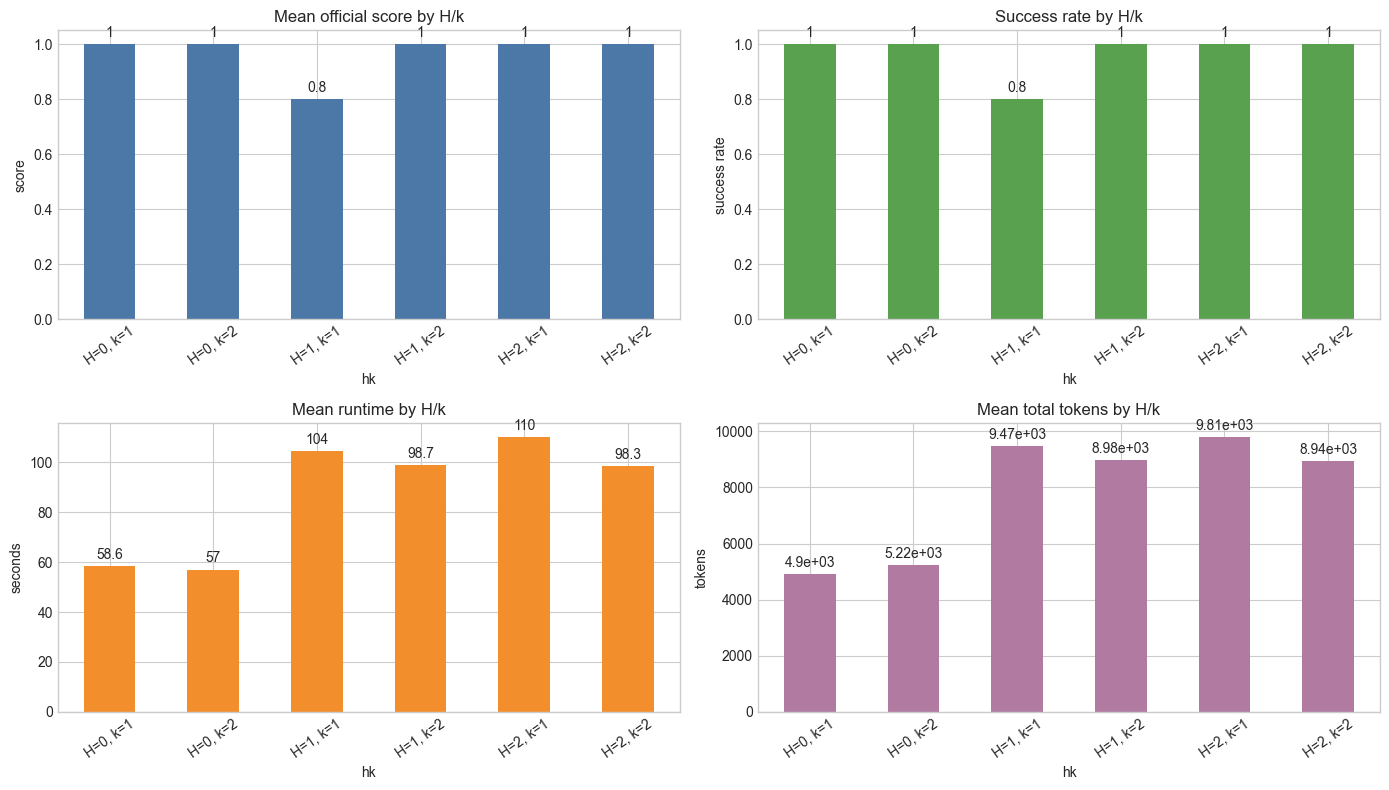

In [6]:
if df.empty:
    print('No results available.')
else:
    completed = df[df['status'] == 'completed'].copy()
    overview = completed.groupby('hk', dropna=False).agg(
        mean_score=('score', 'mean'),
        success_rate=('success', 'mean'),
        mean_runtime_ms=('total_runtime_ms', 'mean'),
        mean_tokens=('total_tokens', 'mean'),
        mean_replans=('num_replans', 'mean'),
    ).sort_index()
    display(overview)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    show_bar(axes[0, 0], overview['mean_score'], 'Mean official score by H/k', ylabel='score', ylim=(0, 1.05), color='#4c78a8')
    show_bar(axes[0, 1], overview['success_rate'], 'Success rate by H/k', ylabel='success rate', ylim=(0, 1.05), color='#59a14f')
    show_bar(axes[1, 0], overview['mean_runtime_ms'] / 1000, 'Mean runtime by H/k', ylabel='seconds', color='#f28e2b')
    show_bar(axes[1, 1], overview['mean_tokens'], 'Mean total tokens by H/k', ylabel='tokens', color='#b07aa1')
    plt.tight_layout()


## Per-Task H/k Plots

Each task gets its own charts. This makes it easier to see whether H/k changes behavior on one environment instead of hiding it inside a mean.



gitlab-44


,site,h,k,score,success,total_steps,total_runtime_ms,total_tokens,executor_tokens,num_planner_calls,num_executor_calls,num_replans,final_url
hk,,,,,,,,,,,,,
"H=0, k=1",gitlab,0,1,1.0,True,2.0,73660.0,4462.0,2000.0,1.0,1.0,0.0,http://localhost:8023/dashboard/todos
"H=0, k=2",gitlab,0,2,1.0,True,2.0,47961.0,4392.0,2000.0,1.0,1.0,0.0,http://localhost:8023/dashboard/todos
"H=1, k=1",gitlab,1,1,1.0,True,2.0,87456.0,8142.0,1996.0,2.0,1.0,0.0,http://localhost:8023/dashboard/todos
"H=1, k=2",gitlab,1,2,1.0,True,2.0,121786.0,9146.0,1990.0,2.0,1.0,0.0,http://localhost:8023/dashboard/todos
"H=2, k=1",gitlab,2,1,1.0,True,2.0,67029.0,5132.0,2010.0,1.0,1.0,0.0,http://localhost:8023/dashboard/todos
"H=2, k=2",gitlab,2,2,1.0,True,2.0,65340.0,5301.0,2010.0,1.0,1.0,0.0,http://localhost:8023/dashboard/todos


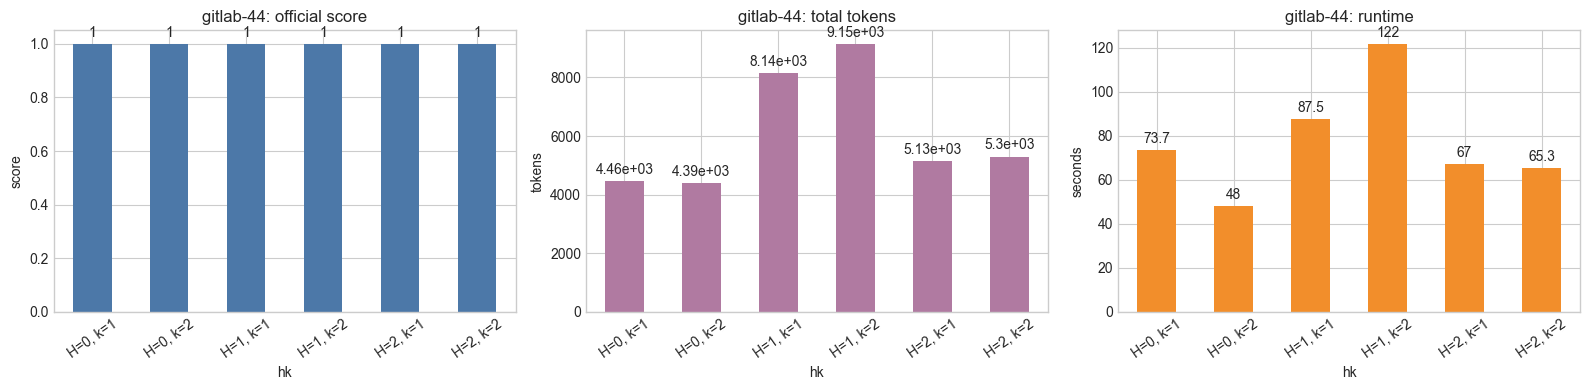


shopping_admin-157


,site,h,k,score,success,total_steps,total_runtime_ms,total_tokens,executor_tokens,num_planner_calls,num_executor_calls,num_replans,final_url
hk,,,,,,,,,,,,,
"H=0, k=1",shopping_admin,0,1,1.0,True,2.0,49249.0,4173.0,1858.0,1.0,1.0,0.0,http://localhost:7780/admin/customer/index
"H=0, k=2",shopping_admin,0,2,1.0,True,2.0,52125.0,4446.0,1855.0,1.0,1.0,0.0,http://localhost:7780/admin/customer/index
"H=1, k=1",shopping_admin,1,1,1.0,True,2.0,44221.0,4069.0,1865.0,1.0,1.0,0.0,http://localhost:7780/admin/customer/index/
"H=1, k=2",shopping_admin,1,2,1.0,True,2.0,62483.0,6344.0,1862.0,2.0,1.0,0.0,http://localhost:7780/admin/customer/index
"H=2, k=1",shopping_admin,2,1,1.0,True,2.0,46277.0,4203.0,1860.0,1.0,1.0,0.0,http://localhost:7780/admin/customer/index
"H=2, k=2",shopping_admin,2,2,1.0,True,2.0,47421.0,4305.0,1857.0,1.0,1.0,0.0,http://localhost:7780/admin/customer/index


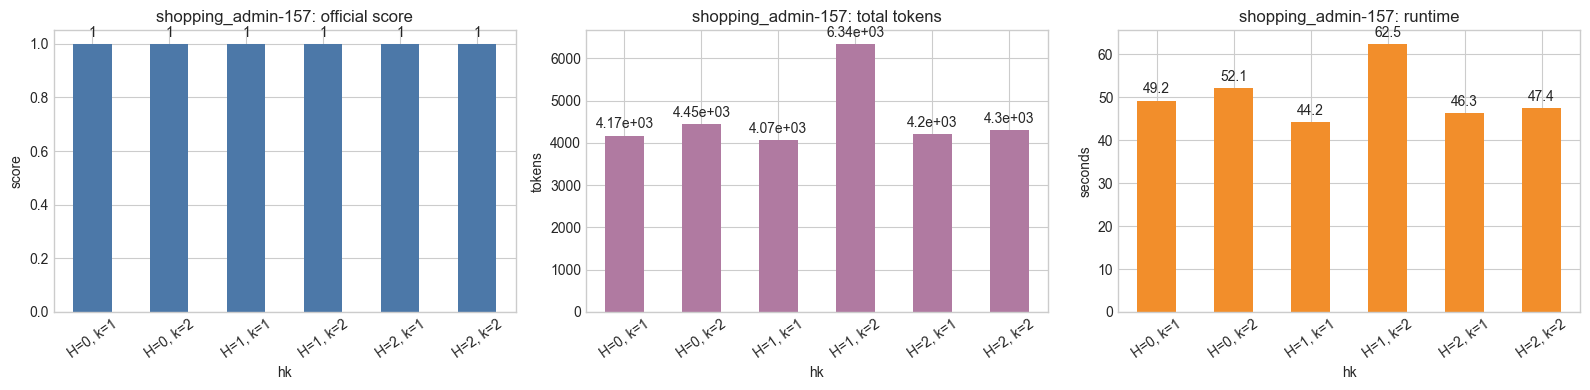


reddit-27


,site,h,k,score,success,total_steps,total_runtime_ms,total_tokens,executor_tokens,num_planner_calls,num_executor_calls,num_replans,final_url
hk,,,,,,,,,,,,,
"H=0, k=1",reddit,0,1,1.0,True,1.0,37019.0,3555.0,1147.0,1.0,1.0,0.0,http://localhost:9999/forums
"H=0, k=2",reddit,0,2,1.0,True,1.0,66984.0,5156.0,1159.0,1.0,1.0,0.0,http://localhost:9999/forums
"H=1, k=1",reddit,1,1,1.0,True,1.0,60848.0,4739.0,1223.0,1.0,1.0,0.0,http://localhost:9999/forums
"H=1, k=2",reddit,1,2,1.0,True,1.0,108971.0,7075.0,1214.0,1.0,1.0,0.0,http://localhost:9999/forums
"H=2, k=1",reddit,2,1,1.0,True,1.0,52379.0,4354.0,1172.0,1.0,1.0,0.0,http://localhost:9999/forums
"H=2, k=2",reddit,2,2,1.0,True,1.0,59332.0,4796.0,1155.0,1.0,1.0,0.0,http://localhost:9999/forums


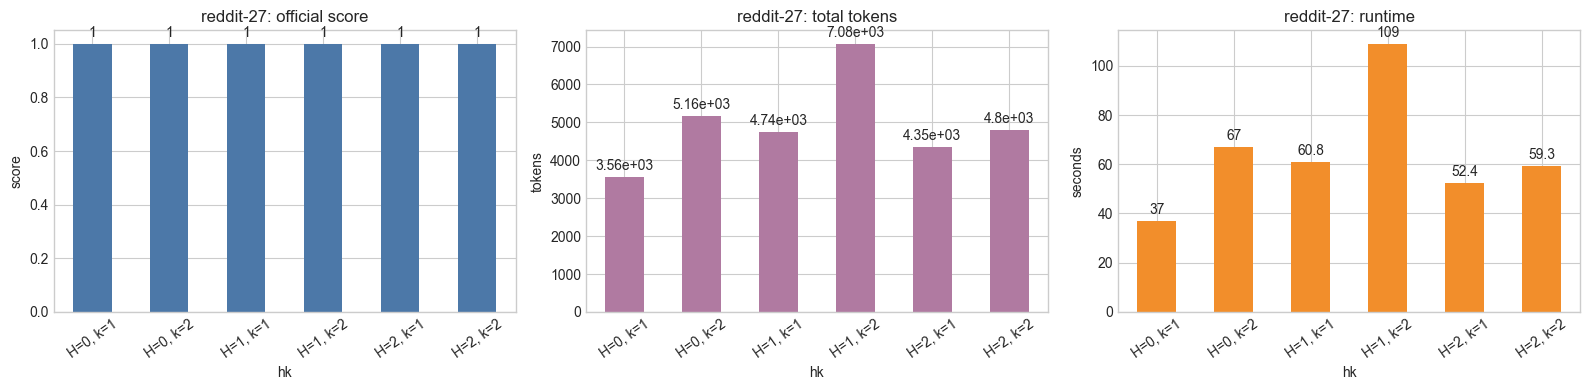


shopping-118


,site,h,k,score,success,total_steps,total_runtime_ms,total_tokens,executor_tokens,num_planner_calls,num_executor_calls,num_replans,final_url
hk,,,,,,,,,,,,,
"H=0, k=1",shopping,0,1,1.0,True,2.0,74297.0,7420.0,4304.0,1.0,2.0,0.0,http://localhost:7770/dentemp-ora-guard-custom-fit-dental-guard-bruxism-night-guard-for-teeth-grinding-two-pack-mouth-guard-for-clenching-teeth-at-night-mouth-guard-for-sleepin...
"H=0, k=2",shopping,0,2,1.0,True,2.0,60889.0,6903.0,4318.0,1.0,2.0,0.0,http://localhost:7770/dentemp-ora-guard-custom-fit-dental-guard-bruxism-night-guard-for-teeth-grinding-two-pack-mouth-guard-for-clenching-teeth-at-night-mouth-guard-for-sleepin...
"H=1, k=1",shopping,1,1,0.0,False,2.0,54522.0,6531.0,4323.0,1.0,2.0,0.0,http://localhost:7770/mouth-guard.html
"H=1, k=2",shopping,1,2,1.0,True,2.0,52786.0,6554.0,4302.0,1.0,2.0,0.0,http://localhost:7770/dentemp-ora-guard-custom-fit-dental-guard-bruxism-night-guard-for-teeth-grinding-two-pack-mouth-guard-for-clenching-teeth-at-night-mouth-guard-for-sleepin...
"H=2, k=1",shopping,2,1,1.0,True,2.0,57470.0,6728.0,4305.0,1.0,2.0,0.0,http://localhost:7770/reazeal-mouth-guard-mouth-guard-for-grinding-teeth-night-guards-for-teeth-grinding-with-travel-case-and-molding-stick-for-teeth-grinding-athletic-protecti...
"H=2, k=2",shopping,2,2,1.0,True,2.0,60898.0,6834.0,4338.0,1.0,2.0,0.0,http://localhost:7770/dentemp-ora-guard-custom-fit-dental-guard-bruxism-night-guard-for-teeth-grinding-two-pack-mouth-guard-for-clenching-teeth-at-night-mouth-guard-for-sleepin...


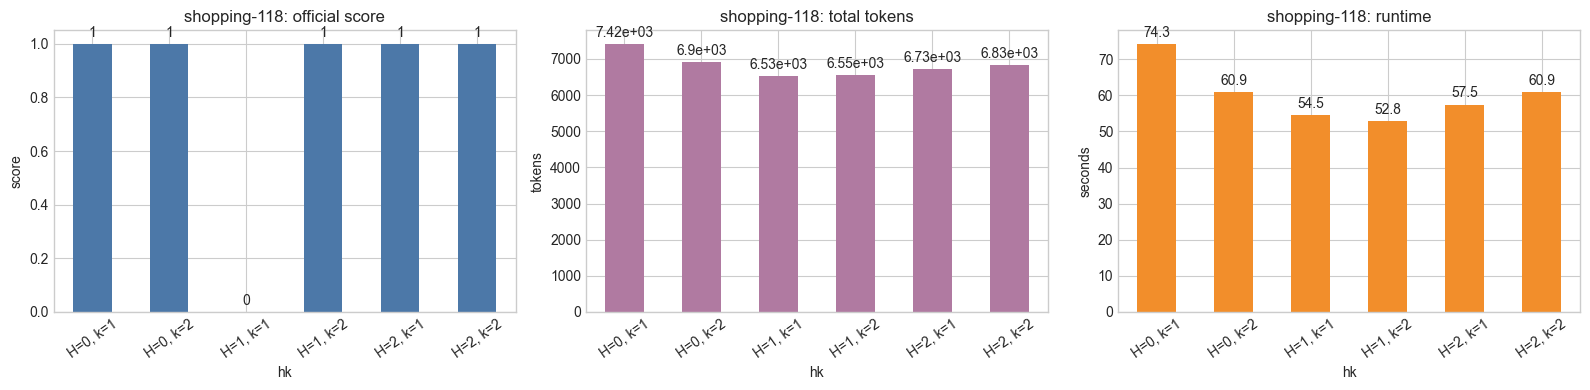


gitlab-105-long


,site,h,k,score,success,total_steps,total_runtime_ms,total_tokens,executor_tokens,num_planner_calls,num_executor_calls,num_replans,final_url
hk,,,,,,,,,,,,,
"H=1, k=1",gitlab,1,1,1.0,True,5.0,275219.0,23875.0,8752.0,3.0,4.0,2.0,http://localhost:8023/OpenAPITools/openapi-generator/-/issues?state=opened&label_name%5B%5D=OpenAPI%20Generator%20CLI
"H=1, k=2",gitlab,1,2,1.0,True,4.0,147649.0,15787.0,6347.0,3.0,3.0,1.0,http://localhost:8023/OpenAPITools/openapi-generator/-/issues?state=opened&label_name%5B%5D=OpenAPI%20Generator%20CLI
"H=2, k=1",gitlab,2,1,1.0,True,6.0,328053.0,28613.0,11281.0,3.0,5.0,3.0,http://localhost:8023/OpenAPITools/openapi-generator/-/issues?state=opened&label_name%5B%5D=OpenAPI%20Generator%20CLI
"H=2, k=2",gitlab,2,2,1.0,True,5.0,258681.0,23439.0,8687.0,3.0,4.0,1.0,http://localhost:8023/OpenAPITools/openapi-generator/-/issues?state=opened&label_name%5B%5D=OpenAPI%20Generator%20CLI


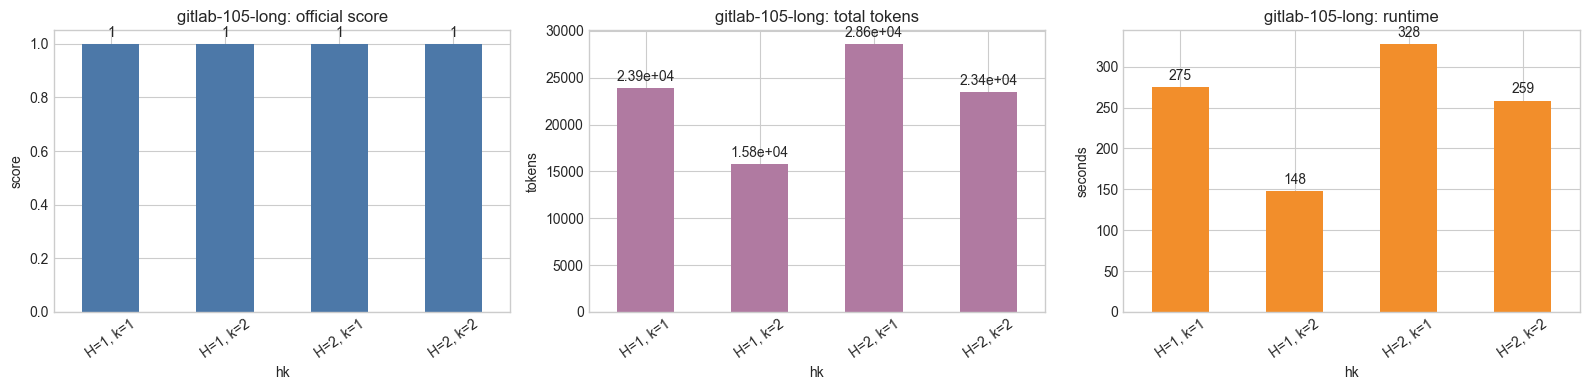

In [7]:
if df.empty:
    print('No results available.')
else:
    completed = df[df['status'] == 'completed'].copy()
    for task_id in EXAMPLE_TASKS:
        task_df = completed[completed['task_id'] == task_id].sort_values(['h', 'k'])
        if task_df.empty:
            print('No completed rows for task', task_id)
            continue
        label = TASK_LABELS.get(task_id, str(task_id))
        task_df = task_df.set_index('hk')
        display_cols = ['site', 'h', 'k', 'score', 'success', 'total_steps', 'total_runtime_ms', 'total_tokens', 'executor_tokens', 'num_planner_calls', 'num_executor_calls', 'num_replans', 'final_url']
        print('\n' + '=' * 80)
        print(label)
        display(task_df[[col for col in display_cols if col in task_df.columns]])

        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        show_bar(axes[0], task_df['score'].fillna(0), f'{label}: official score', ylabel='score', ylim=(0, 1.05), color='#4c78a8')
        show_bar(axes[1], task_df['total_tokens'].fillna(0), f'{label}: total tokens', ylabel='tokens', color='#b07aa1')
        show_bar(axes[2], (task_df['total_runtime_ms'].fillna(0) / 1000), f'{label}: runtime', ylabel='seconds', color='#f28e2b')
        plt.tight_layout()
        plt.show()


## Planner And Executor Artifacts

Use this cell to inspect where the prompt, raw response, parsed action, trace, and official evaluation artifacts were written for one run.


In [8]:
INSPECT_TASK_ID = 105
INSPECT_H = 0
INSPECT_K = 1

if df.empty:
    print('No results available.')
else:
    row = df[(df['task_id'] == INSPECT_TASK_ID) & (df['h'] == INSPECT_H) & (df['k'] == INSPECT_K)]
    if row.empty:
        print('No matching row found.')
    else:
        output_dir = Path(row.iloc[0]['output_dir'])
        paths = {
            'run_summary': output_dir / 'run_summary.json',
            'run_trace': output_dir / 'run_trace.json',
            'planner_calls': output_dir / 'planner_calls.jsonl',
            'executor_calls': output_dir / 'executor_calls.jsonl',
            'step_trace': output_dir / 'step_trace.jsonl',
            'evaluator_signals': output_dir / 'evaluator_signals.jsonl',
            'controller_decisions': output_dir / 'controller_decisions.jsonl',
            'eval_result': output_dir / 'eval_result.json',
        }
        for name, path in paths.items():
            print(f'{name:22s} {path} exists={path.exists()}')
        executor_df = read_jsonl(paths['executor_calls'])
        if not executor_df.empty:
            display(executor_df.head(10))


run_summary            /Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/gitlab/105/h0_k1/105/run_summary.json exists=False
run_trace              /Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/gitlab/105/h0_k1/105/run_trace.json exists=False
planner_calls          /Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/gitlab/105/h0_k1/105/planner_calls.jsonl exists=True
executor_calls         /Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/gitlab/105/h0_k1/105/executor_calls.jsonl exists=True
step_trace             /Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executo

,call_index,subgoal_id,model_name,prompt_tokens,completion_tokens,total_tokens,elapsed_ms,action,action_type,prompt_path,raw_response_path,action_path
0,1,sg2,gemma3:12b,1965,138,2103,13010,"goto(""http://localhost:8023/OpenAPITools/openapi-generator"")",navigate,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/gitlab/105/h0_k1/105/executor_calls/call...,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/gitlab/105/h0_k1/105/executor_calls/call...,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/gitlab/105/h0_k1/105/executor_calls/call...
1,2,sg2,gemma3:12b,2275,167,2442,14959,"goto(""http://localhost:8023/OpenAPITools/openapi-generator/-/issues?state=opened&label_name%5B%5D=OpenAPI%20Generator%20CLI"")",navigate,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/gitlab/105/h0_k1/105/executor_calls/call...,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/gitlab/105/h0_k1/105/executor_calls/call...,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/gitlab/105/h0_k1/105/executor_calls/call...
2,3,sg2,gemma3:12b,1991,139,2130,12549,"noop(""The page showing the list of not yet closed issues in the OpenAPITools/openapi-generator repository that have labels related to OpenAPI Generator CLI is already displayed."")",noop,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/gitlab/105/h0_k1/105/executor_calls/call...,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/gitlab/105/h0_k1/105/executor_calls/call...,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/gitlab/105/h0_k1/105/executor_calls/call...
3,4,sg2,gemma3:12b,2203,131,2334,12808,"noop(""The page showing the list of not yet closed issues in the OpenAPITools/openapi-generator repository that have labels related to OpenAPI Generator CLI is already displayed."")",noop,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/gitlab/105/h0_k1/105/executor_calls/call...,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/gitlab/105/h0_k1/105/executor_calls/call...,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/gitlab/105/h0_k1/105/executor_calls/call...
4,5,sg1,gemma3:12b,2432,136,2568,14539,"noop(""The page showing the list of not yet closed issues in the OpenAPITools/openapi-generator repository that have labels related to OpenAPI Generator CLI is already displayed."")",noop,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/gitlab/105/h0_k1/105/executor_calls/call...,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/gitlab/105/h0_k1/105/executor_calls/call...,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/Masterarbeit/05_Code/runs/hk-test/llm-executor-hk-examples-gemma4-planner-gemma3-executor/gitlab/105/h0_k1/105/executor_calls/call...


## Interpretation Notes

- `H` controls the explicit planning horizon used by the Planner.
- `k` controls how often the runtime Evaluator/Controller checks progress after executed browser actions.
- `total_tokens` combines Planner and Executor token usage where available.
- `executor_tokens` isolates the frequent action-level LLM calls.
- `target_hint_mode none` is the fairer autonomous-agent setting; it should be used for thesis results.
- A run can execute technically and still score `0.0` if the official WebArena-Verified evaluator judges the final state as incorrect.
